## Cell 1 — Install dependencies




!pip install -q \
    "huggingface_hub==0.26.5" \
    "transformers==4.46.3" \
    "diffusers==0.31.0" \
    "accelerate==1.1.1" \
    "safetensors==0.4.5" \
    "gradio==5.9.1" \
    "openai-whisper==20240930"


!apt-get -qq install -y ffmpeg > /dev/null

print("\n✅ Install done.")
print("⚠️  Now click: Runtime → Restart session (Ctrl+M .)")
print("   Then run every cell from the top, in order.")

## Cell 2 — Verify GPU



In [2]:
!nvidia-smi -L

import torch
assert torch.cuda.is_available(), "❌ No GPU. Switch runtime to T4 GPU and restart."
print(f"✅ PyTorch sees: {torch.cuda.get_device_name(0)}")

GPU 0: Tesla T4 (UUID: GPU-80b27744-080f-cfad-e5f0-665bce3a523c)
✅ PyTorch sees: Tesla T4


## Cell 3 — Load Stable Diffusion

In [30]:
import torch
from diffusers import StableDiffusionPipeline

device = "cuda"
dtype = torch.float16

sd_pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=dtype,
    safety_checker=None,
    requires_safety_checker=False,
).to(device)

# Memory optimization: lets us run on the free T4 without OOM
sd_pipe.enable_attention_slicing()

print("✅ Stable Diffusion loaded.")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Stable Diffusion loaded.


## Cell 4 — Load SmolLM2-360M-Instruct

In [25]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

CHAT_MODEL_ID = "HuggingFaceTB/SmolLM2-360M-Instruct"

chat_tokenizer = AutoTokenizer.from_pretrained(CHAT_MODEL_ID)
chat_model = AutoModelForCausalLM.from_pretrained(
    CHAT_MODEL_ID,
    torch_dtype=torch.float16,
).to("cuda")
chat_model.eval()

print("✅ SmolLM2-360M-Instruct loaded.")

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/724M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

✅ SmolLM2-360M-Instruct loaded.


In [26]:
!pip install -q -U openai-whisper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 21.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## Cell 5 — Load Whisper

In [27]:
import whisper

stt_model = whisper.load_model("base")
print("✅ Whisper (base) loaded.")

100%|████████████████████████████████████████| 139M/139M [00:01<00:00, 110MiB/s]


✅ Whisper (base) loaded.


## Cell 6 — Core functions



In [28]:
# ---------- Painting ----------
def paint(prompt: str):
    if not prompt or not prompt.strip():
        return None
    result = sd_pipe(
        prompt.strip(),
        num_inference_steps=25,
        guidance_scale=7.5,
        height=512,
        width=512,
    )
    return result.images[0]

# ---------- Chatting ----------
SYSTEM_PROMPT = (
    "You are RoboMunch, a friendly artist chatbot inspired by Edvard Munch. "
    "Keep replies concise (2-3 sentences)."
)

def chat(user_message: str, history):
    if not user_message or not user_message.strip():
        return ""

    messages = [{"role": "system", "content": SYSTEM_PROMPT}]

    # Handle Gradio history tuples: [[user, bot], [user, bot]]
    if history:
        for user_prev, bot_prev in history:
            if user_prev: messages.append({"role": "user", "content": str(user_prev)})
            if bot_prev: messages.append({"role": "assistant", "content": str(bot_prev)})

    messages.append({"role": "user", "content": user_message.strip()})

    inputs = chat_tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,
    ).to("cuda")

    with torch.no_grad():
        output_ids = chat_model.generate(
            **inputs,
            max_new_tokens=120,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            pad_token_id=chat_tokenizer.eos_token_id,
        )

    new_tokens = output_ids[0][inputs["input_ids"].shape[-1]:]
    return chat_tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

# ---------- Speech-to-text ----------
def transcribe(audio_path):
    if audio_path is None:
        return ""
    result = stt_model.transcribe(audio_path, fp16=True)
    return result["text"].strip()

print("✅ Core functions fixed and ready.")

✅ Core functions fixed and ready.


## Cell 7 — Smoke test (optional but recommended)

Quick sanity check that all three pieces work before launching the UI.

💬 Chat test:
"Munch's 'The Scream' - the depths of human despair."

🎨 Painting test (this takes ~10s)...


  0%|          | 0/25 [00:00<?, ?it/s]

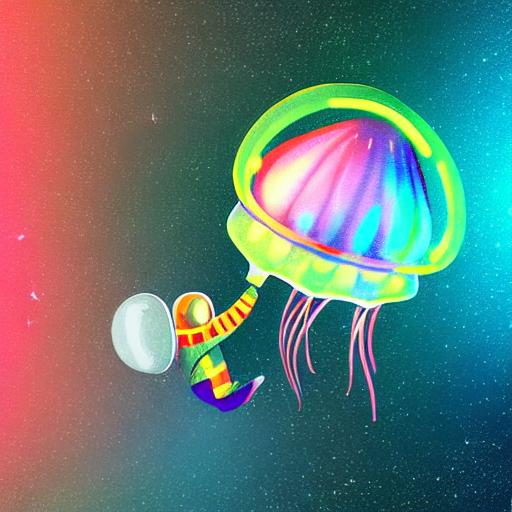

In [31]:
# Test the chatbot
print("💬 Chat test:")
print(chat("Hello! Suggest a digital art prompt under 20 words.", []))
print()

# Test the painter (~10 seconds on T4)
print("🎨 Painting test (this takes ~10s)...")
img = paint("a tiny astronaut riding a glowing jellyfish, digital art")
img

In [32]:
## ===== Cell 7.5: Load icons from Colab Files =====
import base64
from pathlib import Path

def file_to_data_url(path):
    """Read a local image file and return a data: URL we can embed in CSS/HTML."""
    p = Path(path)
    ext = p.suffix.lower().lstrip(".")
    mime = "jpeg" if ext in ("jpg", "jpeg") else ext   # png stays png
    data = base64.b64encode(p.read_bytes()).decode("ascii")
    return f"data:image/{mime};base64,{data}"

# Adjust file names / extensions to match your uploads in the Files panel
PAINT_ICON = file_to_data_url("paint.jpeg")
SEND_ICON  = file_to_data_url("send.jpeg")
MIC_ICON   = file_to_data_url("mic.jpeg")
MUNCH_IMG  = file_to_data_url("munch.jpeg")

print("✅ Icons loaded from /content/")

✅ Icons loaded from /content/


In [17]:
import os

required_files = ['paint.jpeg', 'send.jpeg', 'mic.jpeg', 'munch.jpeg']
missing_files = [f for f in required_files if not os.path.exists(f)]

if not missing_files:
    print("✅ Tüm dosyalar mevcut, hata başka bir sebeple ilgili olabilir.")
else:
    print(f"❌ Eksik dosyalar: {missing_files}")
    print("Lütfen bu dosyaları sol taraftaki dosya paneline yükleyin.")

✅ Tüm dosyalar mevcut, hata başka bir sebeple ilgili olabilir.


## Cell 8 — Build the Gradio UI



In [33]:
import gradio as gr
import traceback

CSS = """
/* Page background */
.gradio-container {
    background: linear-gradient(180deg, #1a0e08 0%, #3a2418 50%, #c89968 100%) !important;
    font-family: 'Georgia', 'Garamond', serif !important;
    max-width: 680px !important;
    margin: 0 auto !important;
    padding: 0 !important;
}

/* Header */
#robomunch-header {
    display: flex; align-items: center; justify-content: center;
    gap: 14px; padding: 22px 0 6px 0;
}
#robomunch-header h1 {
    font-size: 42px; letter-spacing: 4px; margin: 0;
    color: #f4e4cc; font-weight: normal;
}
#robomunch-header h1 .munch { color: #d4a253; font-style: italic; }
#robomunch-header img.avatar {
    width: 56px; height: 56px; border-radius: 50%;
    border: 2px solid #d4a253;
    box-shadow: 0 0 12px rgba(212,162,83,0.4);
    object-fit: cover;
}

/* Studio titles */
.studio-title {
    text-align: center; color: #f4e4cc; font-size: 26px;
    font-style: italic; margin: 22px 0 14px 0; letter-spacing: 1px;
}

/* Inputs */
.gradio-container textarea, .gradio-container input[type='text'] {
    background: linear-gradient(145deg, #5a3a26, #2e1c12) !important;
    border: 1px solid rgba(212,162,83,0.25) !important;
    border-radius: 28px !important;
    color: #f4e4cc !important;
    font-family: 'Georgia', serif !important;
    font-style: italic !important;
    padding: 14px 22px !important;
    box-shadow: inset 0 2px 6px rgba(0,0,0,0.3) !important;
}
.gradio-container textarea::placeholder, .gradio-container input::placeholder {
    color: rgba(244,228,204,0.5) !important; font-style: italic !important;
}

/* Image and chat panels */
#image-output, #chatbox {
    background: linear-gradient(145deg, #4a2e20, #2a1810) !important;
    border: 1px solid rgba(212,162,83,0.25) !important;
    border-radius: 18px !important;
    padding: 8px !important;
    box-shadow: 0 4px 16px rgba(0,0,0,0.4) !important;
}
#image-output img { border-radius: 12px !important; }
#chatbox { min-height: 240px; padding: 14px !important; border-radius: 22px !important; }

/* Round gold buttons (paint + send) with embedded icons */
#paint-btn, #send-btn {
    background: linear-gradient(145deg, #f0c674, #b8843a) !important;
    border: none !important;
    border-radius: 50% !important;
    width: 48px !important; height: 48px !important;
    min-width: 48px !important; max-width: 48px !important;
    box-shadow: 0 3px 10px rgba(0,0,0,0.5) !important;
    padding: 0 !important;
    background-size: 60% 60% !important;
    background-repeat: no-repeat !important;
    background-position: center !important;
    color: transparent !important;
    font-size: 0 !important;
    cursor: pointer !important;
}
#paint-btn { background-image: url(""" + PAINT_ICON + """), linear-gradient(145deg, #f0c674, #b8843a) !important; }
#send-btn  { background-image: url(""" + SEND_ICON  + """), linear-gradient(145deg, #f0c674, #b8843a) !important; }
#paint-btn:hover, #send-btn:hover { transform: scale(1.08); transition: transform 0.15s ease; }

/* Mic button — round, dark, with embedded mic icon */
#voice-input { max-width: 56px !important; min-width: 56px !important; flex: 0 0 56px !important; }
#voice-input > div, #voice-input .wrap, #voice-input .audio-container {
    background: transparent !important; border: none !important; padding: 0 !important;
}
#voice-input button {
    background: url(""" + MIC_ICON + """) center/55% no-repeat,
                linear-gradient(145deg, #5a3a26, #2e1c12) !important;
    border: 1px solid rgba(212,162,83,0.4) !important;
    border-radius: 50% !important;
    width: 48px !important; height: 48px !important; min-width: 48px !important;
    color: transparent !important; font-size: 0 !important;
    box-shadow: 0 3px 10px rgba(0,0,0,0.5) !important;
}
#voice-input button:hover { transform: scale(1.08); transition: transform 0.15s ease; }
#voice-input label, #voice-input .label-wrap,
#voice-input .source-selection, #voice-input .controls,
#voice-input audio, #voice-input .player {
    display: none !important;
}

footer { display: none !important; }
"""

def on_paint(prompt):
    return paint(prompt)

def on_send(user_msg, history):
    try:
        if not user_msg or not user_msg.strip():
            return history, ""
        bot_reply = chat(user_msg, history)
        history = (history or []) + [[user_msg, bot_reply]]
        return history, ""
    except Exception as e:
        print("--- CHAT ERROR ---")
        traceback.print_exc()
        return history, f"Error: {str(e)}"

def on_voice(audio_path, current_text):
    try:
        text = transcribe(audio_path)
        return (current_text + " " + text).strip() if current_text else text
    except Exception as e:
        print("--- VOICE ERROR ---")
        traceback.print_exc()
        return current_text

with gr.Blocks(css=CSS, title="RoboMunch") as demo:
    gr.HTML(f"""
        <div id='robomunch-header'>
            <h1>ROBO <span class='munch'>MUNCH</span></h1>
            <img class='avatar' src='{MUNCH_IMG}' alt='Munch' />
        </div>
    """)

    gr.HTML("<div class='studio-title'>Art Studio</div>")

    image_output = gr.Image(
        label="", elem_id="image-output", height=380, show_label=False,
    )

    with gr.Row():
        prompt_input = gr.Textbox(
            placeholder="Type your prompt here.",
            show_label=False, lines=2, scale=8,
        )
        paint_btn = gr.Button("paint", elem_id="paint-btn", scale=0, min_width=50)

    gr.HTML("<div class='studio-title'>Chat Studio</div>")

    chatbot = gr.Chatbot(
        label="", elem_id="chatbox", height=260, show_label=False, type="tuples"
    )

    with gr.Row():
        voice_input = gr.Audio(
            sources=["microphone"], type="filepath",
            label="", show_label=False, scale=0, elem_id="voice-input",
        )
        chat_input = gr.Textbox(
            placeholder="Type your message here.",
            show_label=False, lines=1, scale=6,
        )
        send_btn = gr.Button("send", elem_id="send-btn", scale=0, min_width=50)

    paint_btn.click(fn=on_paint, inputs=prompt_input, outputs=image_output)
    send_btn.click(fn=on_send, inputs=[chat_input, chatbot], outputs=[chatbot, chat_input])
    chat_input.submit(fn=on_send, inputs=[chat_input, chatbot], outputs=[chatbot, chat_input])
    voice_input.stop_recording(fn=on_voice, inputs=[voice_input, chat_input], outputs=chat_input)

print("✅ UI defined with Debug handling.")

/tmp/ipykernel_4325/3566347896.py:131: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=CSS, title="RoboMunch") as demo:
/tmp/ipykernel_4325/3566347896.py:154: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  chatbot = gr.Chatbot(
/tmp/ipykernel_4325/3566347896.py:154: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in your chatbot.
  chatbot = gr.Chatbot(


✅ UI defined with Debug handling.


## Cell 9 — Launch



In [34]:
demo.queue().launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a6ea1e6a5027e05336.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### 🚀 GitHub'a Pushlama Adımları

Bu bölümdeki bilgileri kendi GitHub bilgilerinizle doldurun.

In [37]:
import os

# --- AYARLAR ---
GITHUB_TOKEN = "REMOVED_FOR_SECURITY"
GITHUB_USER = "ZEGE-E"
GITHUB_REPO = "MiniProje3"
GITHUB_EMAIL = "zeynep.gogus@outlook.com.tr"

# Git yapılandırması
!git config --global user.email "{GITHUB_EMAIL}"
!git config --global user.name "{GITHUB_USER}"

# Repo URL'si (Kimlik doğrulama için token eklendi)
repo_url = f"https://{GITHUB_TOKEN}@github.com/{GITHUB_USER}/{GITHUB_REPO}.git"

# Proje klasörünü oluştur ve dosyaları kopyala
!mkdir -p workspace
!cp *.jpeg workspace/ 2>/dev/null || :

# Notebook'un kendisini kaydetmek için (Colab'da bu hücreyi manuel kaydettikten sonra çalıştırmak en iyisidir)
# Mevcut notebook ismini 'RoboMunch.ipynb' olarak varsayıyoruz
import json
import requests

print("✅ Yapılandırma ve URL hazır.")

✅ Yapılandırma ve URL hazır.


In [39]:
%cd /content/workspace
!git init
!git branch -M main
!git remote remove origin 2>/dev/null || :
!git remote add origin {repo_url}
!git add .
!git commit -m "Initial commit: RoboMunch App and assets" --allow-empty

try:
    print("📤 Push işlemi başlatılıyor...")
    !git push -u origin main --force
    print(f"\n🚀 BAŞARILI! https://github.com/{GITHUB_USER}/{GITHUB_REPO} adresini kontrol edin.")
except:
    print("\n❌ Hata: Lütfen GitHub token yetkilerini (repo) ve repo ismini kontrol edin.")

%cd /content

/content/workspace
Reinitialized existing Git repository in /content/workspace/.git/
[main 6abbbe9] Initial commit: RoboMunch App and assets
📤 Push işlemi başlatılıyor...
Enumerating objects: 1, done.
Counting objects: 100% (1/1), done.
Writing objects: 100% (1/1), 218 bytes | 218.00 KiB/s, done.
Total 1 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/ZEGE-E/MiniProje3.git
   899f0d5..6abbbe9  main -> main
Branch 'main' set up to track remote branch 'main' from 'origin'.

🚀 BAŞARILI! https://github.com/ZEGE-E/MiniProje3 adresini kontrol edin.
/content
